## EDA

In [208]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/Users/tanaphan/Downloads/flat.csv")
df_og = df.copy()
df.shape

(311991, 12)

In [209]:
df.head()

,com_num,name,sector,region,account_type,accounts_overdue,nonlloyds_charges,has_nonlloyds_charge,yrs_since_nonlloyds_chg,n_distinct_lenders,age_years,label
0,13172868,369 TECHNICAL LTD,C: Manufacturing,Wales,total-exemption-full,0,0,0,50.0,0,4.911704,0
1,07852962,369 UPLAND ROAD RTM COMPANY LIMITED,L: Real Estate,London,micro-entity,0,0,0,50.0,0,14.121834,0
2,14568066,369 VORTEX LIMITED,K: Finance/Insurance,East Midlands,micro-entity,0,0,0,50.0,0,2.995209,0
3,15623849,369 WATCH PARTS LTD,G: Retail/Wholesale,London,total-exemption-full,0,0,0,50.0,0,1.735797,0
4,16023853,369MULTI LTD,G: Retail/Wholesale,North West,micro-entity,0,0,0,50.0,0,1.207392,0


In [210]:
df.dtypes

com_num                     object
name                        object
sector                      object
region                      object
account_type                object
accounts_overdue             int64
nonlloyds_charges            int64
has_nonlloyds_charge         int64
yrs_since_nonlloyds_chg    float64
n_distinct_lenders           int64
age_years                  float64
label                        int64
dtype: object

In [211]:
df.isnull().sum()

com_num                        0
name                           0
sector                         0
region                     13833
account_type                   0
accounts_overdue               0
nonlloyds_charges              0
has_nonlloyds_charge           0
yrs_since_nonlloyds_chg        0
n_distinct_lenders             0
age_years                      0
label                          0
dtype: int64

### Check "Label"

In [212]:
df["label"].value_counts()

label
0    303572
1      8419
Name: count, dtype: int64

In [213]:
df["label"].value_counts(normalize=True) * 100

label
0    97.301525
1     2.698475
Name: proportion, dtype: float64

### Check Unique Values


In [214]:
df.nunique()

com_num                    311991
name                       311990
sector                         21
region                         12
account_type                    5
accounts_overdue                2
nonlloyds_charges             113
has_nonlloyds_charge            2
yrs_since_nonlloyds_chg      8273
n_distinct_lenders             35
age_years                   15356
label                           2
dtype: int64

In [215]:
df["accounts_overdue"].unique()

array([0, 1])

## CLEANING

In [216]:
# Mode imputation
mode_region = df["region"].mode()[0]
df["region"] = df["region"].fillna(mode_region)

In [217]:
df.isnull().sum()

com_num                    0
name                       0
sector                     0
region                     0
account_type               0
accounts_overdue           0
nonlloyds_charges          0
has_nonlloyds_charge       0
yrs_since_nonlloyds_chg    0
n_distinct_lenders         0
age_years                  0
label                      0
dtype: int64

In [218]:
df.head()

,com_num,name,sector,region,account_type,accounts_overdue,nonlloyds_charges,has_nonlloyds_charge,yrs_since_nonlloyds_chg,n_distinct_lenders,age_years,label
0,13172868,369 TECHNICAL LTD,C: Manufacturing,Wales,total-exemption-full,0,0,0,50.0,0,4.911704,0
1,07852962,369 UPLAND ROAD RTM COMPANY LIMITED,L: Real Estate,London,micro-entity,0,0,0,50.0,0,14.121834,0
2,14568066,369 VORTEX LIMITED,K: Finance/Insurance,East Midlands,micro-entity,0,0,0,50.0,0,2.995209,0
3,15623849,369 WATCH PARTS LTD,G: Retail/Wholesale,London,total-exemption-full,0,0,0,50.0,0,1.735797,0
4,16023853,369MULTI LTD,G: Retail/Wholesale,North West,micro-entity,0,0,0,50.0,0,1.207392,0


## MODELING

In [219]:
df.dtypes

com_num                     object
name                        object
sector                      object
region                      object
account_type                object
accounts_overdue             int64
nonlloyds_charges            int64
has_nonlloyds_charge         int64
yrs_since_nonlloyds_chg    float64
n_distinct_lenders           int64
age_years                  float64
label                        int64
dtype: object

In [220]:
num_cols = ["nonlloyds_charges", "yrs_since_nonlloyds_chg", "n_distinct_lenders","age_years"]
cat_cols = ["sector", "region", "account_type"]
bool_cols = ["accounts_overdue", "has_nonlloyds_charge"]
target_col = "label"

feature_cols = cat_cols + num_cols + bool_cols
feature_cols

['sector',
 'region',
 'account_type',
 'nonlloyds_charges',
 'yrs_since_nonlloyds_chg',
 'n_distinct_lenders',
 'age_years',
 'accounts_overdue',
 'has_nonlloyds_charge']

In [221]:
from sklearn.model_selection import train_test_split

RS = 42

X = df[feature_cols]
y = df[target_col]
iden = df[["com_num", "name"]]

X_train, X_test, y_train, y_test, iden_train, iden_test = train_test_split(
    X, y, iden, test_size=0.2, random_state=RS, stratify=y
)

In [222]:
y_train.sum()

np.int64(6735)

In [223]:
y_test.sum()

np.int64(1684)

### Logistic Regression

In [224]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

RS = 42

preprocess_lr = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
], remainder="passthrough")

model_lr = LogisticRegression(
    max_iter=100,
    class_weight="balanced",
    random_state=RS)

pipe_lr = Pipeline([
    ("prep", preprocess_lr),
    ("clf", model_lr)
])

pipe_lr.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [225]:
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, average_precision_score, precision_recall_curve, roc_curve

y_pred_lr = pipe_lr.predict(X_test)

print(classification_report(y_test, y_pred_lr, target_names=["NOT Lloyds Customer", "Lloyds Customer"]))

                     precision    recall  f1-score   support

NOT Lloyds Customer       0.99      0.81      0.89     60715
    Lloyds Customer       0.10      0.77      0.18      1684

           accuracy                           0.81     62399
          macro avg       0.55      0.79      0.54     62399
       weighted avg       0.97      0.81      0.87     62399



In [226]:
confusion_matrix(y_test, y_pred_lr)

array([[49309, 11406],
       [  379,  1305]])

In [227]:
y_proba_lr = pipe_lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"ROC-AUC: {auc_lr}")

ROC-AUC: 0.873575535830639


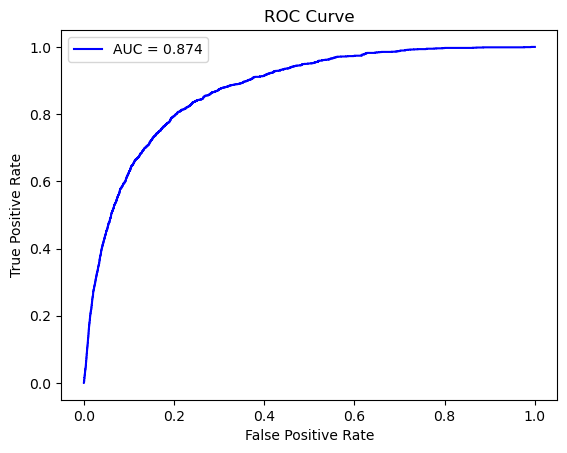

In [228]:
fpr, tpr, _ = roc_curve(y_test, y_proba_lr)
plt.plot(fpr, tpr, color="blue", label=f"AUC = {auc_lr:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [229]:
ap_lr = average_precision_score(y_test, y_proba_lr)
print(f"Average Precision: {ap_lr}")

Average Precision: 0.18197260042801044


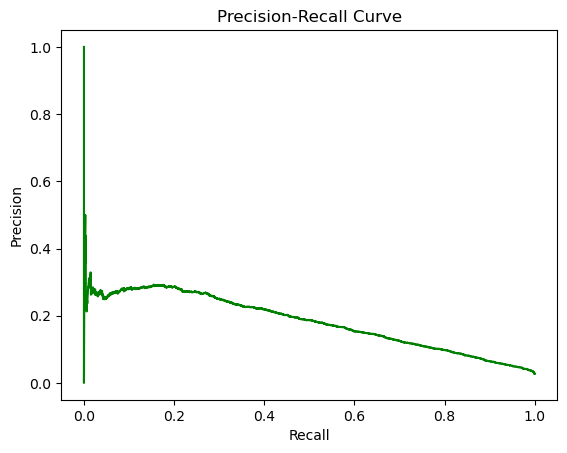

In [230]:
prec, rec, _ = precision_recall_curve(y_test, y_proba_lr)
plt.plot(rec, prec, color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

#### precision @ K

In [231]:
def precision_at_k(y_true, y_proba, k):
    results = pd.DataFrame({"y_true": y_true, "y_score": y_proba})
    top_k = results.sort_values("y_score", ascending=False).head(k) # Sort by predicted score, descending
    precision = top_k["y_true"].sum() / k
    return precision

In [232]:
# Get precision at different K
for k in [10, 50, 100, 500]:
    p_at_k = precision_at_k(y_test, y_proba_lr, k)
    print(f"Precision@{k}: {p_at_k:.3f}")

Precision@10: 0.500
Precision@50: 0.240
Precision@100: 0.270
Precision@500: 0.278


In [233]:
top10_lr = iden_test.assign(
    y_true=y_test,
    y_score=y_proba_lr
).sort_values("y_score", ascending=False).head(10)

top10_lr

,com_num,name,y_true,y_score
86056,00138853,AERONAUTICAL & GENERAL INSTRUMENTS LIMITED,0,0.999977
5029,00029325,44 NORTH LIMITED,0,0.999972
147320,00038357,AMBLESIDE ASSEMBLY ROOMS COMPANY LIMITED,0,0.999963
270643,00024166,"BOROUGH OF GRAVESEND CONSERVATIVE CLUB,LIMITED...",0,0.999951
220846,00103844,ASPREY HOLDINGS LIMITED,1,0.999945
131097,00403053,ALLIED COMMERCIAL EXPORTERS LIMITED,1,0.999940
226683,00038755,ATALANTA INVESTMENTS LIMITED,0,0.999933
140001,00357934,ALTON ESTATES (PLYMOUTH) LIMITED,1,0.999928
47754,00131358,ABBEY MANOR GROUP LIMITED,1,0.999918
204937,00091360,ARTHUR BRADSHAW LIMITED,1,0.999861


In [234]:
# top10_lr = pd.DataFrame({
#     "y_true": y_test,
#     "y_score": y_proba_lr
# }).join(df[["com_num", "name"]]).sort_values("y_score", ascending=False).head(10)

# top10_lr

### Random Forest

In [235]:
from sklearn.ensemble import RandomForestClassifier

preprocess_rf = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

model_rf = RandomForestClassifier(
    n_estimators=100, # default
    # max_depth=6, # default = None
    class_weight="balanced",
    random_state=RS)

pipe_rf = Pipeline([
    ("prep", preprocess_rf),
    ("clf_rf", model_rf)
])

pipe_rf.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf_rf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [236]:
y_pred_rf = pipe_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf, target_names=["NOT Lloyds Customer", "Lloyds Customer"]))

                     precision    recall  f1-score   support

NOT Lloyds Customer       0.98      0.99      0.98     60715
    Lloyds Customer       0.16      0.09      0.12      1684

           accuracy                           0.96     62399
          macro avg       0.57      0.54      0.55     62399
       weighted avg       0.95      0.96      0.96     62399



In [237]:
confusion_matrix(y_test, y_pred_rf)

array([[59919,   796],
       [ 1530,   154]])

In [238]:
y_proba_rf = pipe_rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"ROC-AUC: {auc_rf}")

ROC-AUC: 0.7813030801006924


In [239]:
ap_rf = average_precision_score(y_test, y_proba_rf)
print(f"Average Precision: {ap_rf}")

Average Precision: 0.13298122641714794


#### Precision @ K

In [240]:
for k in [10, 50, 100, 500]:
    p_at_k = precision_at_k(y_test, y_proba_rf, k)
    print(f"Precision@{k}: {p_at_k:.3f}")

Precision@10: 0.800
Precision@50: 0.440
Precision@100: 0.360
Precision@500: 0.186


In [241]:
top10_rf = iden_test.assign(
    y_true=y_test,
    y_score=y_proba_rf
).sort_values("y_score", ascending=False).head(10)

top10_rf

,com_num,name,y_true,y_score
230465,03596604,ATLAS HOTELS (BRISTOL NORTH) LIMITED,1,1.00
113257,SC111549,ALAN FRANCE MANAGEMENT LIMITED,1,0.98
112817,SC229750,ALAM PROPERTIES LIMITED,1,0.97
244696,SC229553,AVERTON LANDSCAPES LIMITED,1,0.97
204632,02552255,ARTESIAN CHALLENGER LIMITED,1,0.96
101618,SC224650,AIRIUS DESTRATIFICATION SOLUTIONS LIMITED,1,0.96
46310,SC212599,ABACO LIMITED,1,0.95
48410,SC188310,ABBEYVIEW KIDS CLUB LIMITED,0,0.95
256369,SC214253,BLUEHOUSE SCOTLAND LTD.,0,0.95
230481,03328699,ATLAS HOTELS (GROUP 4 PROPERTY 2) LIMITED,1,0.94


In [242]:
# top10_rf = pd.DataFrame({
#     "y_true": y_test,
#     "y_score": y_proba_rf
# }).join(df[["com_num", "name"]]).sort_values("y_score", ascending=False).head(10)

# top10_rf

### XGBoost

In [243]:
# !pip install xgboost

In [244]:
from xgboost import XGBClassifier

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum() # sum(negative instances) / sum(positive instances)
print(f"scale_pos_weight: {scale_pos_weight:.2f}")

preprocess_xgb = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
], remainder="passthrough")

model_xgb = XGBClassifier(
    n_estimators=100, # default
    max_depth=6, # default
    learning_rate=0.3, # default
    scale_pos_weight=scale_pos_weight,
    random_state=RS,
)

pipe_xgb = Pipeline([
    ("prep", preprocess_xgb),
    ("clf_xgb", model_xgb)
])

pipe_xgb.fit(X_train, y_train)

scale_pos_weight: 36.06


,steps,"[('prep', ...), ('clf_xgb', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [245]:
y_pred_xgb = pipe_xgb.predict(X_test)

print(classification_report(y_test, y_pred_xgb, target_names=["NOT Lloyds Customer", "Lloyds Customer"]))

                     precision    recall  f1-score   support

NOT Lloyds Customer       0.99      0.83      0.90     60715
    Lloyds Customer       0.11      0.77      0.20      1684

           accuracy                           0.83     62399
          macro avg       0.55      0.80      0.55     62399
       weighted avg       0.97      0.83      0.89     62399



In [246]:
confusion_matrix(y_test, y_pred_xgb)

array([[50442, 10273],
       [  390,  1294]])

In [247]:
y_proba_xgb = pipe_xgb.predict_proba(X_test)[:, 1]
auc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"ROC-AUC: {auc_xgb}")

ROC-AUC: 0.87871219120211


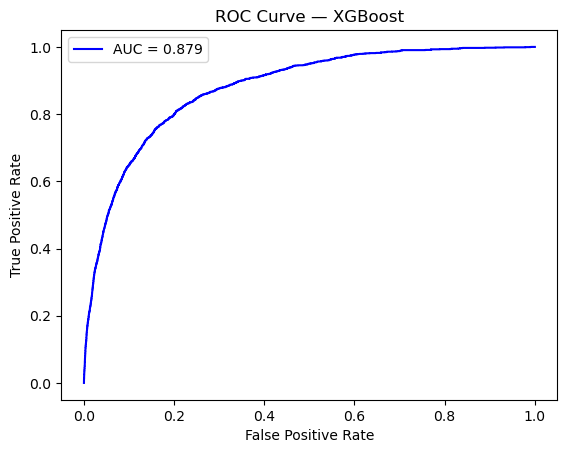

In [248]:
fpr, tpr, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr, tpr, color="blue", label=f"AUC = {auc_xgb:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — XGBoost")
plt.legend()
plt.show()

In [249]:
ap_xgb = average_precision_score(y_test, y_proba_xgb)
print(f"Average Precision: {ap_xgb}")

Average Precision: 0.23142557167195724


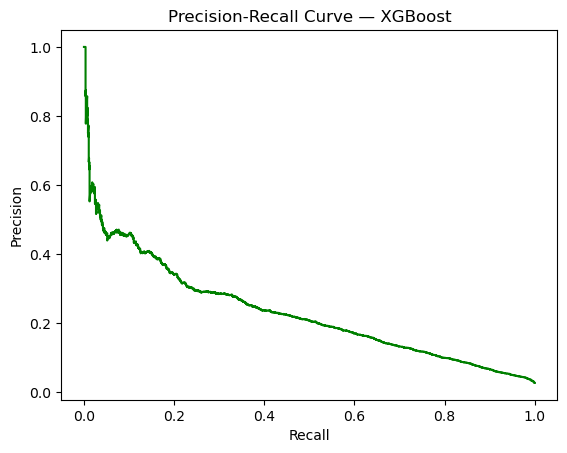

In [250]:
prec, rec, _ = precision_recall_curve(y_test, y_proba_xgb)
plt.plot(rec, prec, color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — XGBoost")
plt.show()

#### Precision @ K

In [251]:
for k in [10, 50, 100, 500]:
    p_at_k = precision_at_k(y_test, y_proba_xgb, k)
    print(f"Precision@{k}: {p_at_k:.3f}")

Precision@10: 0.800
Precision@50: 0.600
Precision@100: 0.540
Precision@500: 0.414


In [252]:
top10_xgb = iden_test.assign(
    y_true=y_test,
    y_score=y_proba_xgb
).sort_values("y_score", ascending=False).head(10)

top10_xgb

,com_num,name,y_true,y_score
131097,00403053,ALLIED COMMERCIAL EXPORTERS LIMITED,1,0.996497
117132,02706818,ALCOMAX (INVESTMENTS) LTD,1,0.995627
230486,SC208635,ATLAS HOTELS (LUTON AIRPORT) LIMITED,1,0.995468
193809,SC044769,ARDTORNISH ESTATE COMPANY LIMITED,1,0.995049
157901,SC173743,ANCASTER COURT LIMITED,1,0.994487
66652,SC162925,ACREPOINT LIMITED,1,0.994410
36899,SC032334,A.M. & A. CALDER FARMS LIMITED,0,0.994066
20009,SC202866,A & I PROPERTY MANAGEMENT LIMITED,1,0.993614
20597,SC184227,A & M INVESTMENTS (ABERDEEN) LIMITED,0,0.992457
213649,01445624,ASHFIELD ESTATES LIMITED,1,0.992177


In [253]:
# top10_xgb = pd.DataFrame({
#     "y_true": y_test,
#     "y_score": y_proba_xgb
# }).join(df[["com_num", "name"]]).sort_values("y_score", ascending=False).head(10)

# top10_xgb

### Nueral Network

In [254]:
from sklearn.neural_network import MLPClassifier

preprocess_nn = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols),
    ("num", StandardScaler(), num_cols),
], remainder="passthrough")

model_nn = MLPClassifier(
    hidden_layer_sizes=(100, ), # default = (100,)
    activation="relu", # default
    alpha=1e-4, # default
    learning_rate_init=1e-3, # default
    max_iter=200, # default
    early_stopping=True, #default = False
    random_state=RS,
)

pipe_nn = Pipeline([
    ("prep", preprocess_nn),
    ("clf_nn", model_nn)
])

pipe_nn.fit(X_train, y_train)

,steps,"[('prep', ...), ('clf_nn', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [255]:
y_pred_nn = pipe_nn.predict(X_test)

print(classification_report(y_test, y_pred_nn, target_names=["NOT Lloyds Customer", "Lloyds Customer"]))

                     precision    recall  f1-score   support

NOT Lloyds Customer       0.97      1.00      0.99     60715
    Lloyds Customer       0.54      0.05      0.09      1684

           accuracy                           0.97     62399
          macro avg       0.76      0.52      0.54     62399
       weighted avg       0.96      0.97      0.96     62399



In [256]:
confusion_matrix(y_test, y_pred_nn)

array([[60642,    73],
       [ 1598,    86]])

In [257]:
y_proba_nn = pipe_nn.predict_proba(X_test)[:, 1]
auc_nn = roc_auc_score(y_test, y_proba_nn)
print(f"ROC-AUC: {auc_nn}")

ROC-AUC: 0.8900134394115413


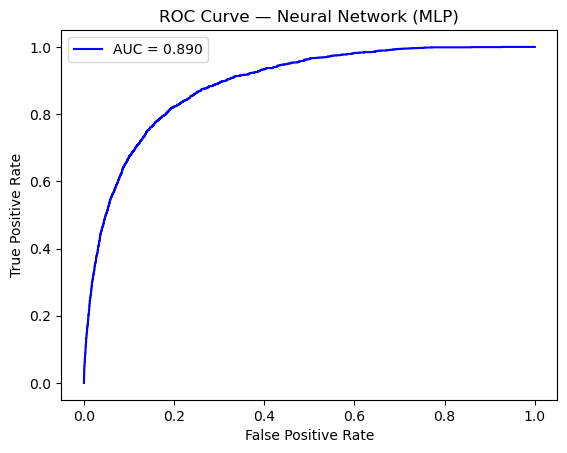

In [258]:
fpr, tpr, _ = roc_curve(y_test, y_proba_nn)
plt.plot(fpr, tpr, color="blue", label=f"AUC = {auc_nn:.3f}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Neural Network (MLP)")
plt.legend()
plt.show()

In [259]:
ap_nn = average_precision_score(y_test, y_proba_nn)
print(f"Average Precision: {ap_nn}")

Average Precision: 0.24610680339990126


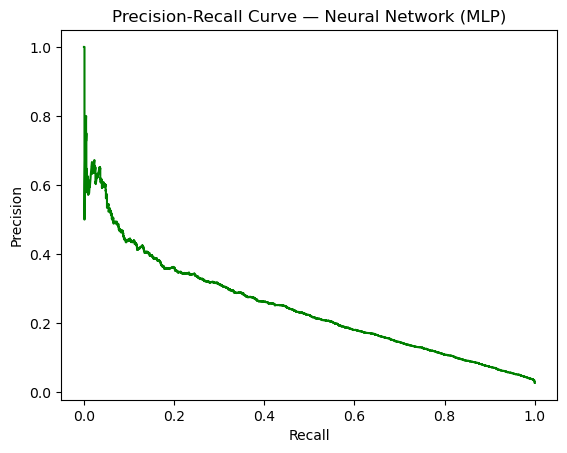

In [260]:
prec, rec, _ = precision_recall_curve(y_test, y_proba_nn)
plt.plot(rec, prec, color="green")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Neural Network (MLP)")
plt.show()

#### Precision @ K

In [261]:
for k in [10, 50, 100, 500]:
    p_at_k = precision_at_k(y_test, y_proba_nn, k)
    print(f"Precision@{k}: {p_at_k:.3f}")

Precision@10: 0.800
Precision@50: 0.640
Precision@100: 0.620
Precision@500: 0.416


In [262]:
top10_nn = iden_test.assign(
    y_true=y_test,
    y_score=y_proba_nn
).sort_values("y_score", ascending=False).head(10)

top10_nn

,com_num,name,y_true,y_score
131097,00403053,ALLIED COMMERCIAL EXPORTERS LIMITED,1,0.966957
140001,00357934,ALTON ESTATES (PLYMOUTH) LIMITED,1,0.946291
36899,SC032334,A.M. & A. CALDER FARMS LIMITED,0,0.844373
304136,01886042,19 ENTERTAINMENT LIMITED,0,0.827659
120888,SC037629,ALEXANDER SIMPSON LIMITED,1,0.823182
230486,SC208635,ATLAS HOTELS (LUTON AIRPORT) LIMITED,1,0.819952
48712,SC041790,ABBOTSHALL EVANTON LIMITED,1,0.807545
170150,SC060731,ANNISTON FARMS (ARBROATH) LIMITED,1,0.795996
193809,SC044769,ARDTORNISH ESTATE COMPANY LIMITED,1,0.792799
167046,SC063957,ANGUSFIELD PROPERTY COMPANY LIMITED,1,0.788611


In [263]:
# top10_nn = pd.DataFrame({
#     "y_true": y_test,
#     "y_score": y_proba_nn
# }).join(df[["com_num", "name"]]).sort_values("y_score", ascending=False).head(10)

# top10_nn

### Model Comparison

#### NOTE: all of the models are not fine-tuned yet

In [264]:
models_proba = {
    "Logistic Regression": y_proba_lr,
    "Random Forest": y_proba_rf,
    "XGBoost": y_proba_xgb,
    "Neural Network (MLP)": y_proba_nn,
}
models_auc = {
    "Logistic Regression": auc_lr,
    "Random Forest": auc_rf,
    "XGBoost": auc_xgb,
    "Neural Network (MLP)": auc_nn,
}
models_ap = {
    "Logistic Regression": ap_lr,
    "Random Forest": ap_rf,
    "XGBoost": ap_xgb,
    "Neural Network (MLP)": ap_nn,
}

rows = []
for name, proba in models_proba.items():
    row = {
        "Model": name,
        "ROC-AUC": models_auc[name],
        "Average Precision": models_ap[name],
    }
    for k in [10, 50, 100, 500]:
        row[f"Precision@{k}"] = precision_at_k(y_test, proba, k)
    rows.append(row)

comparison = pd.DataFrame(rows)
comparison

,Model,ROC-AUC,Average Precision,Precision@10,Precision@50,Precision@100,Precision@500
0,Logistic Regression,0.873576,0.181973,0.5,0.24,0.27,0.278
1,Random Forest,0.781303,0.132981,0.8,0.44,0.36,0.186
2,XGBoost,0.878712,0.231426,0.8,0.60,0.54,0.414
3,Neural Network (MLP),0.890013,0.246107,0.8,0.64,0.62,0.416
